<a href="https://colab.research.google.com/github/adityawzj345-png/ML-Classification-Project/blob/main/cardiovascular_disease_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Importing

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("../content/cardio_train.csv", sep=";")

In [4]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1.0,1.0,0.0,0.0,1.0,0.0
1,1,20228,1,156,85.0,140,90,3.0,1.0,0.0,0.0,1.0,1.0
2,2,18857,1,165,64.0,130,70,3.0,1.0,0.0,0.0,0.0,1.0
3,3,17623,2,169,82.0,150,100,1.0,1.0,0.0,0.0,1.0,1.0
4,4,17474,1,156,56.0,100,60,1.0,1.0,0.0,0.0,0.0,0.0


In [5]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 25072
Columns: 13


In [6]:
df.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25072 entries, 0 to 25071
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           25072 non-null  int64  
 1   age          25072 non-null  int64  
 2   gender       25072 non-null  int64  
 3   height       25072 non-null  int64  
 4   weight       25072 non-null  float64
 5   ap_hi        25072 non-null  int64  
 6   ap_lo        25072 non-null  int64  
 7   cholesterol  25071 non-null  float64
 8   gluc         25071 non-null  float64
 9   smoke        25071 non-null  float64
 10  alco         25071 non-null  float64
 11  active       25071 non-null  float64
 12  cardio       25071 non-null  float64
dtypes: float64(7), int64(6)
memory usage: 2.5 MB


In [8]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,25072.000000,25072.000000,25072.000000,25072.000000,25072.000000,25072.000000,25072.000000,25071.000000,25071.000000,25071.000000,25071.000000,25071.000000,25071.000000
mean,17892.715260,19457.369775,1.350830,164.399330,74.173455,127.334357,97.624601,1.363169,1.224881,0.091181,0.054764,0.804555,0.496390
std,10352.852917,2473.629583,0.477239,8.205966,14.352088,75.955404,211.248336,0.677531,0.570660,0.287872,0.227524,0.396551,0.499997
min,0.000000,10798.000000,1.000000,55.000000,30.000000,-140.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,8921.750000,17641.750000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,17900.500000,19696.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,26849.500000,21316.000000,2.000000,170.000000,82.000000,140.000000,90.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,35802.000000,23690.000000,2.000000,250.000000,200.000000,11500.000000,10000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


Cleanning


In [10]:
df.isnull().sum()

,0
id,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,1
gluc,1
smoke,1


In [11]:
#df = df.drop_duplicates()
print(f"Duplicate Rows: {df.duplicated().sum()}")


Duplicate Rows: 0


In [12]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

id: 25072 unique values
age: 6987 unique values
gender: 2 unique values
height: 88 unique values
weight: 195 unique values
ap_hi: 117 unique values
ap_lo: 112 unique values
cholesterol: 3 unique values
gluc: 3 unique values
smoke: 2 unique values
alco: 2 unique values
active: 2 unique values
cardio: 2 unique values


In [13]:
df["cardio"].value_counts()

,count
cardio,
0.0,12626
1.0,12445


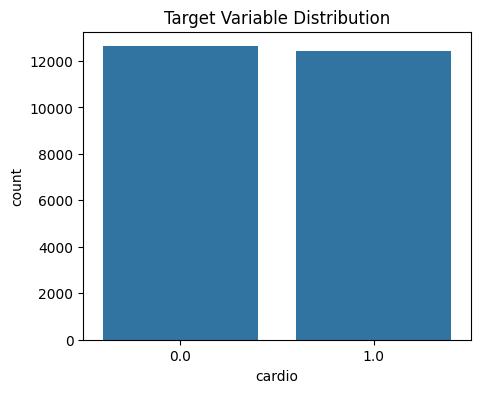

In [14]:
plt.figure(figsize=(5,4))
sns.countplot(x="cardio", data=df)
plt.title("Target Variable Distribution")
plt.show()

In [15]:
print(df["ap_hi"].describe())
print(df["ap_lo"].describe())

count    25072.000000
mean       127.334357
std         75.955404
min       -140.000000
25%        120.000000
50%        120.000000
75%        140.000000
max      11500.000000
Name: ap_hi, dtype: float64
count    25072.000000
mean        97.624601
std        211.248336
min          0.000000
25%         80.000000
50%         80.000000
75%         90.000000
max      10000.000000
Name: ap_lo, dtype: float64


In [16]:
print(df["ap_hi"].describe())
print(df["ap_lo"].describe())

count    25072.000000
mean       127.334357
std         75.955404
min       -140.000000
25%        120.000000
50%        120.000000
75%        140.000000
max      11500.000000
Name: ap_hi, dtype: float64
count    25072.000000
mean        97.624601
std        211.248336
min          0.000000
25%         80.000000
50%         80.000000
75%         90.000000
max      10000.000000
Name: ap_lo, dtype: float64


In [17]:
print("Height < 100 cm:", (df["height"] < 100).sum())

Height < 100 cm: 12


In [18]:
print("Height > 250 cm:", (df["height"] > 250).sum())

Height > 250 cm: 0


In [19]:
print("Height > 250 cm:", (df["height"] > 250).sum())

Height > 250 cm: 0


In [20]:
print("Weight > 250 kg:", (df["weight"] > 250).sum())

Weight > 250 kg: 0


In [21]:
print("Systolic BP <= 0:", (df["ap_hi"] <= 0).sum())

Systolic BP <= 0: 4


In [22]:
print("Diastolic BP <= 0:", (df["ap_lo"] <= 0).sum())

Diastolic BP <= 0: 6


In [23]:
print("Systolic < Diastolic:", (df["ap_hi"] < df["ap_lo"]).sum())

Systolic < Diastolic: 452


In [24]:
df[df["height"] < 100]

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
224,309,21800,2,76,55.0,120,80,1.0,1.0,0.0,0.0,1.0,0.0
7598,10843,14661,2,70,72.0,120,8,1.0,1.0,0.0,0.0,1.0,0.0
8171,11662,17646,2,97,170.0,160,100,1.0,1.0,1.0,0.0,1.0,1.0
12770,18218,19594,1,75,168.0,120,80,1.0,1.0,1.0,0.0,1.0,1.0
13265,18928,22456,2,71,68.0,120,80,3.0,1.0,0.0,0.0,1.0,0.0
14323,20459,22005,1,67,57.0,120,90,1.0,1.0,0.0,0.0,1.0,1.0
15167,21686,15812,1,70,68.0,120,80,1.0,1.0,0.0,0.0,0.0,0.0
16699,23859,19680,2,74,98.0,140,90,1.0,1.0,0.0,0.0,1.0,1.0
17277,24690,17530,1,98,45.0,12,80,1.0,1.0,0.0,0.0,1.0,0.0
22542,32207,14538,1,68,65.0,100,60,1.0,1.0,0.0,0.0,0.0,0.0


In [25]:
df[df["ap_hi"] <= 0]

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
4607,6525,15281,1,165,78.0,-100,80,2.0,1.0,0.0,0.0,1.0,0.0
16021,22881,22108,2,161,90.0,-115,70,1.0,1.0,0.0,0.0,1.0,0.0
20536,29313,15581,1,153,54.0,-100,70,1.0,1.0,0.0,0.0,1.0,0.0
23988,34295,18301,1,162,74.0,-140,90,1.0,1.0,0.0,0.0,1.0,1.0


In [26]:
df[df["ap_lo"] <= 0]

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
2014,2845,22712,2,167,59.0,906,0,1.0,1.0,0.0,0.0,1.0,0.0
13489,19258,14965,2,150,60.0,130,0,1.0,1.0,0.0,0.0,0.0,0.0
16459,23512,20457,1,156,50.0,138,0,3.0,1.0,0.0,0.0,1.0,1.0
17381,24837,18226,1,164,78.0,138,0,1.0,1.0,0.0,0.0,1.0,0.0
22923,32749,21182,2,166,68.0,149,0,1.0,1.0,0.0,0.0,1.0,1.0
23867,34120,16131,1,161,92.0,906,0,2.0,1.0,0.0,0.0,1.0,1.0


In [27]:
df[df["ap_hi"] < df["ap_lo"]].head(20)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
228,314,17489,2,183,98.0,160,1100,1.0,2.0,1.0,0.0,1.0,1.0
241,334,21932,2,157,60.0,160,1000,2.0,1.0,0.0,0.0,0.0,1.0
260,357,18217,1,150,83.0,140,800,1.0,1.0,0.0,0.0,1.0,1.0
329,458,23407,1,176,63.0,160,1000,2.0,2.0,0.0,0.0,0.0,1.0
345,482,18704,1,154,81.0,140,1000,2.0,1.0,0.0,0.0,1.0,1.0
473,680,15226,1,150,95.0,150,1033,1.0,1.0,0.0,0.0,1.0,1.0
474,681,19099,1,156,65.0,120,150,2.0,1.0,0.0,0.0,1.0,0.0
559,805,20430,2,173,101.0,200,1000,1.0,1.0,0.0,0.0,1.0,1.0
567,815,21281,1,168,78.0,14,90,2.0,1.0,0.0,0.0,1.0,1.0
613,886,18963,1,165,92.0,140,1000,1.0,1.0,1.0,0.0,1.0,1.0


In [28]:
# Remove unrealistic heights
df = df[df["height"] >= 100]

# Remove non-positive blood pressure values
df = df[(df["ap_hi"] > 0) & (df["ap_lo"] > 0)]

# Remove records where systolic <= diastolic
df = df[df["ap_hi"] > df["ap_lo"]]

# Reset index
df.reset_index(drop=True, inplace=True)

In [29]:
print(df.shape)

print("Height < 100 :", (df["height"] < 100).sum())
print("Systolic <= 0 :", (df["ap_hi"] <= 0).sum())
print("Diastolic <= 0 :", (df["ap_lo"] <= 0).sum())
print("Systolic <= Diastolic :", (df["ap_hi"] <= df["ap_lo"]).sum())

(24602, 13)
Height < 100 : 0
Systolic <= 0 : 0
Diastolic <= 0 : 0
Systolic <= Diastolic : 0


In [30]:
df["ap_hi"].describe()

,ap_hi
count,24602.000000
mean,127.304487
std,75.949189
min,60.000000
25%,120.000000
50%,120.000000
75%,140.000000
max,11500.000000


In [31]:
df["ap_lo"].describe()

,ap_lo
count,24602.000000
mean,81.223681
std,9.571661
min,7.000000
25%,80.000000
50%,80.000000
75%,90.000000
max,170.000000


In [32]:
# Keep only realistic blood pressure values
df = df[
    (df["ap_hi"] >= 80) & (df["ap_hi"] <= 250) &
    (df["ap_lo"] >= 40) & (df["ap_lo"] <= 200)
]

# Reset index
df.reset_index(drop=True, inplace=True)

In [33]:
df[["ap_hi", "ap_lo"]].describe()

,ap_hi,ap_lo
count,24575.000000,24575.000000
mean,126.628199,81.272269
std,16.676416,9.417068
min,80.000000,40.000000
25%,120.000000,80.000000
50%,120.000000,80.000000
75%,140.000000,90.000000
max,220.000000,170.000000


In [34]:
print(df.shape)

(24575, 13)


In [36]:
df = pd.read_csv("../content/cardio_train.csv", sep=";")

**EDA**(Exploratory Data Analysis)

In [37]:
df["age_year"] = df["age"] / 365.25

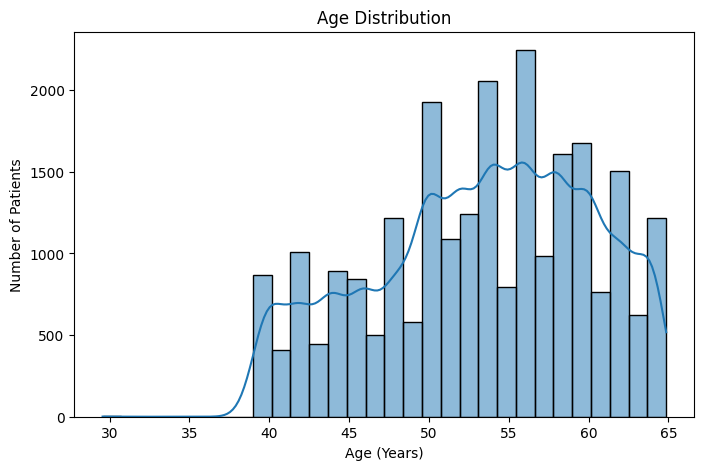

In [38]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="age_year",
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age (Years)")
plt.ylabel("Number of Patients")

plt.show()

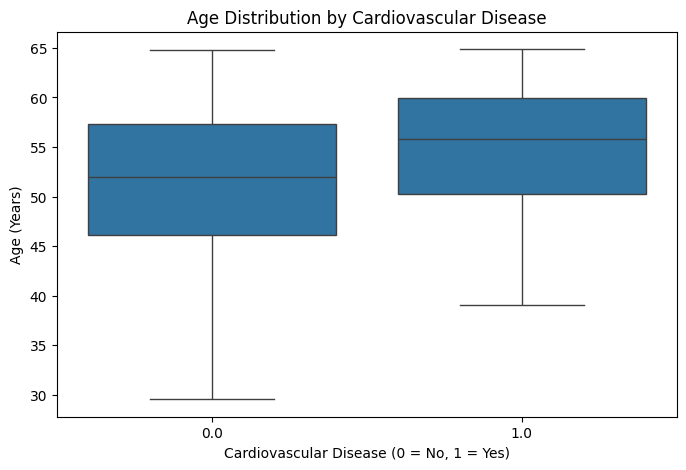

In [39]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="cardio",
    y="age_year"
)

plt.title("Age Distribution by Cardiovascular Disease")
plt.xlabel("Cardiovascular Disease (0 = No, 1 = Yes)")
plt.ylabel("Age (Years)")

plt.show()

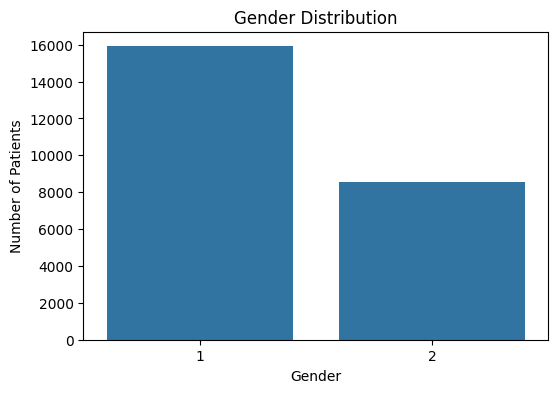

In [40]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="gender"
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.show()

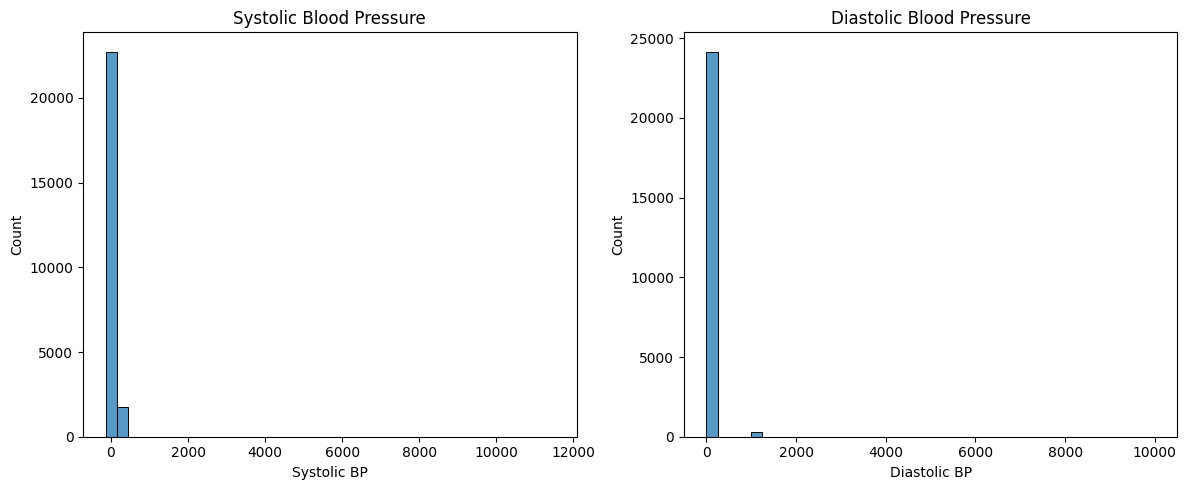

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.histplot(
    data=df,
    x="ap_hi",
    bins=40,
    ax=axes[0]
)

axes[0].set_title("Systolic Blood Pressure")
axes[0].set_xlabel("Systolic BP")

sns.histplot(
    data=df,
    x="ap_lo",
    bins=40,
    ax=axes[1]
)

axes[1].set_title("Diastolic Blood Pressure")
axes[1].set_xlabel("Diastolic BP")

plt.tight_layout()
plt.show()

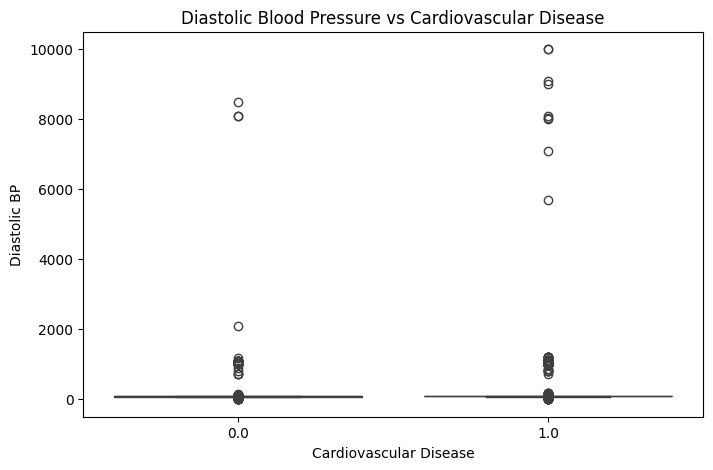

In [42]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="cardio",
    y="ap_lo"
)

plt.title("Diastolic Blood Pressure vs Cardiovascular Disease")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("Diastolic BP")

plt.show()

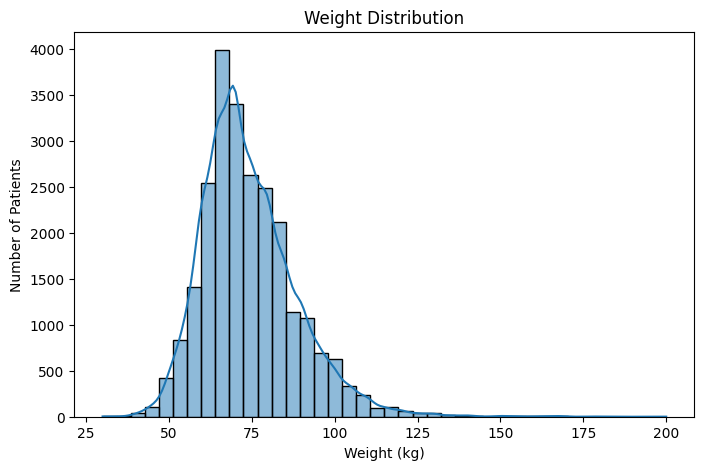

In [44]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="weight",
    bins=40,
    kde=True
)

plt.title("Weight Distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Number of Patients")

plt.show()

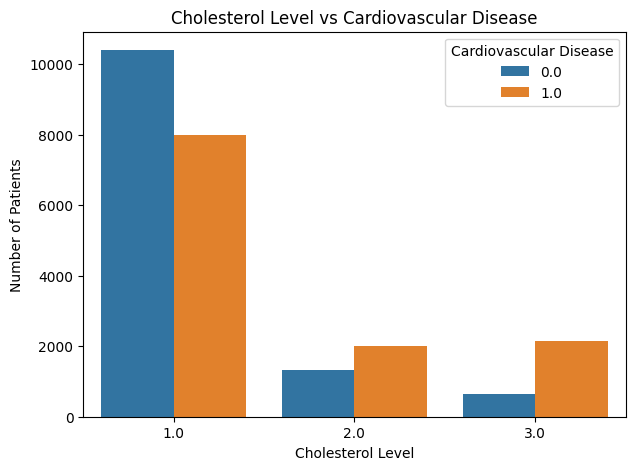

In [45]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="cholesterol",
    hue="cardio"
)

plt.title("Cholesterol Level vs Cardiovascular Disease")
plt.xlabel("Cholesterol Level")
plt.ylabel("Number of Patients")

plt.legend(title="Cardiovascular Disease")

plt.show()

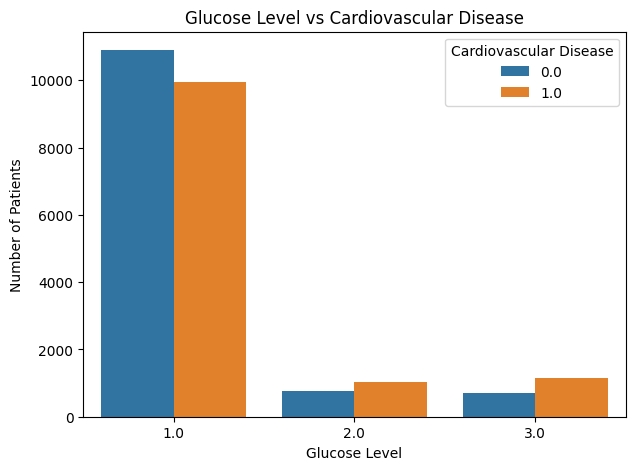

In [46]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="gluc",
    hue="cardio"
)

plt.title("Glucose Level vs Cardiovascular Disease")
plt.xlabel("Glucose Level")
plt.ylabel("Number of Patients")

plt.legend(title="Cardiovascular Disease")

plt.show()

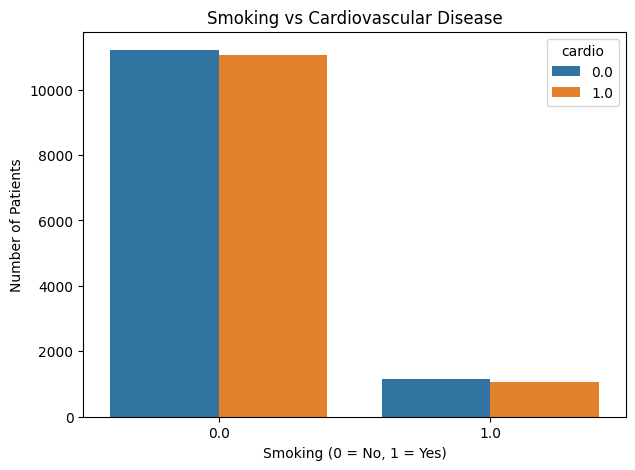

In [47]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="smoke",
    hue="cardio"
)

plt.title("Smoking vs Cardiovascular Disease")
plt.xlabel("Smoking (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")

plt.show()

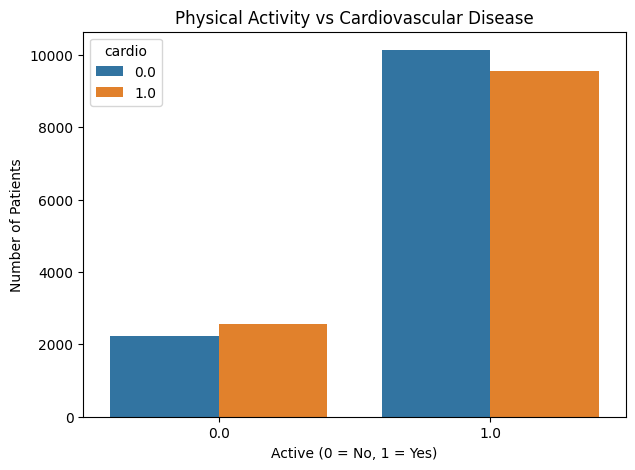

In [48]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="active",
    hue="cardio"
)

plt.title("Physical Activity vs Cardiovascular Disease")
plt.xlabel("Active (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")

plt.show()

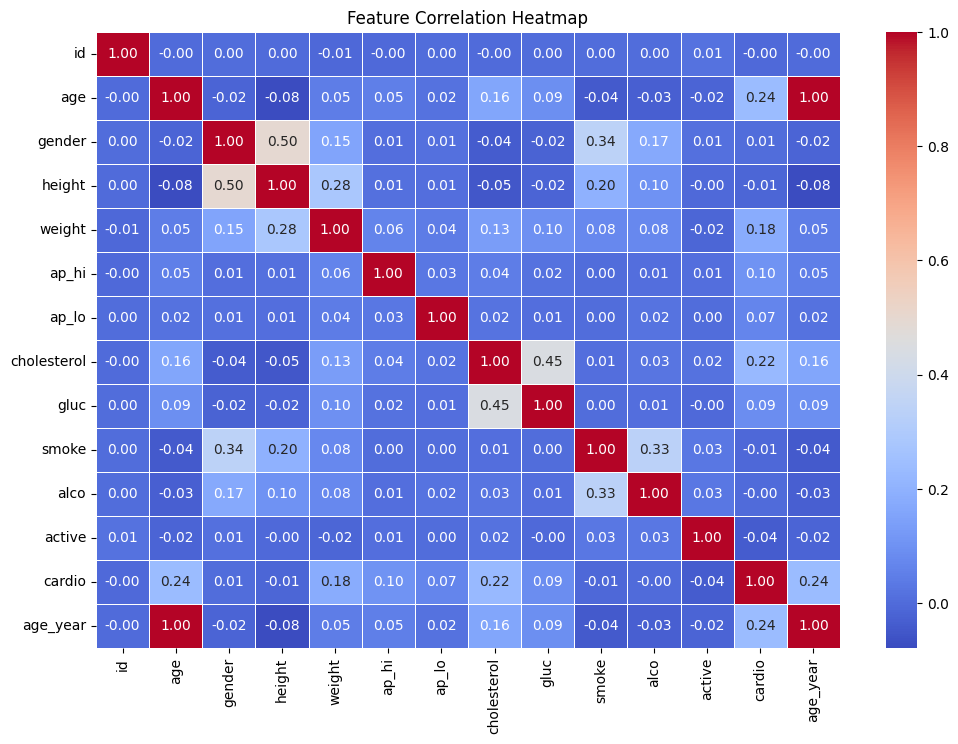

In [49]:
plt.figure(figsize=(12,8))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [55]:
df["bmi"] = df["weight"] / ((df["height"] / 100) ** 2)

In [56]:
df["bmi"].describe()

,bmi
count,24491.000000
mean,27.546532
std,6.367119
min,10.726644
25%,23.875115
50%,26.346494
75%,30.119376
max,298.666667


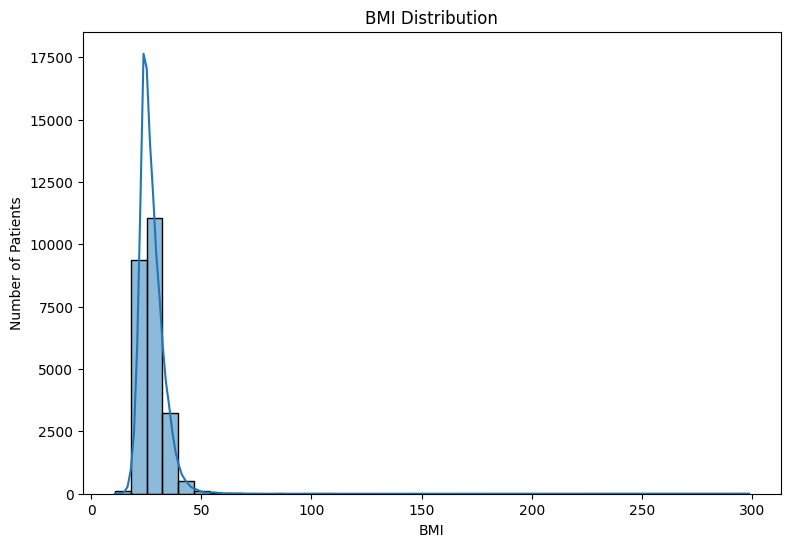

In [57]:
plt.figure(figsize=(9,6))

sns.histplot(
    data=df,
    x="bmi",
    bins=40,
    kde=True
)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Number of Patients")

plt.show()

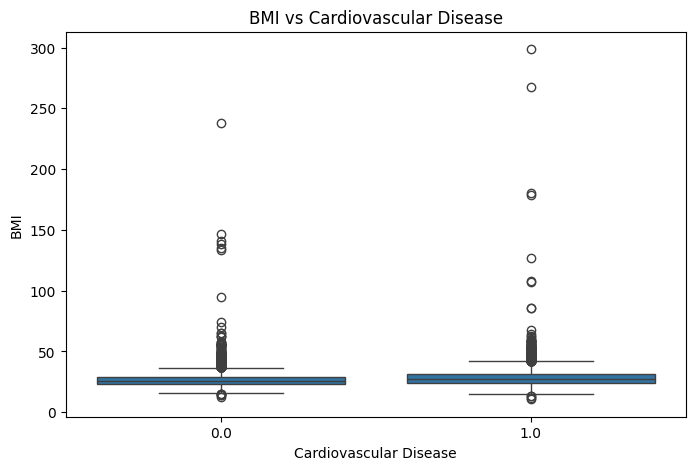

In [58]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="cardio",
    y="bmi"
)

plt.title("BMI vs Cardiovascular Disease")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("BMI")

plt.show()

In [62]:
df[["ap_hi", "ap_lo"]].describe()

,ap_hi,ap_lo
count,24490.000000,24490.000000
mean,127.339649,97.693916
std,76.791717,213.061680
min,-140.000000,0.000000
25%,120.000000,80.000000
50%,120.000000,80.000000
75%,140.000000,90.000000
max,11500.000000,10000.000000


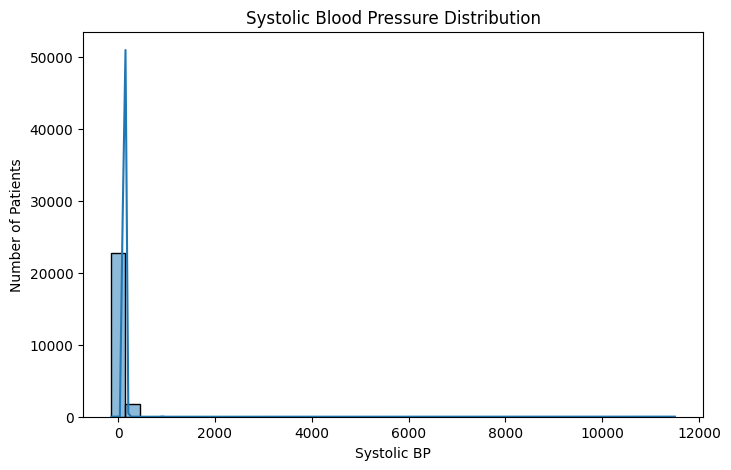

In [63]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="ap_hi",
    bins=40,
    kde=True
)

plt.title("Systolic Blood Pressure Distribution")
plt.xlabel("Systolic BP")
plt.ylabel("Number of Patients")

plt.show()

In [64]:
target_correlation = (
    df.corr(numeric_only=True)["cardio"]
    .sort_values(ascending=False)
)

print(target_correlation)

cardio         1.000000
age            0.235036
age_year       0.235036
cholesterol    0.224918
weight         0.179661
bmi            0.158265
ap_hi          0.102468
gluc           0.086584
ap_lo          0.066029
gender         0.005032
alco          -0.000133
id            -0.003974
smoke         -0.010104
height        -0.012328
active        -0.039422
Name: cardio, dtype: float64


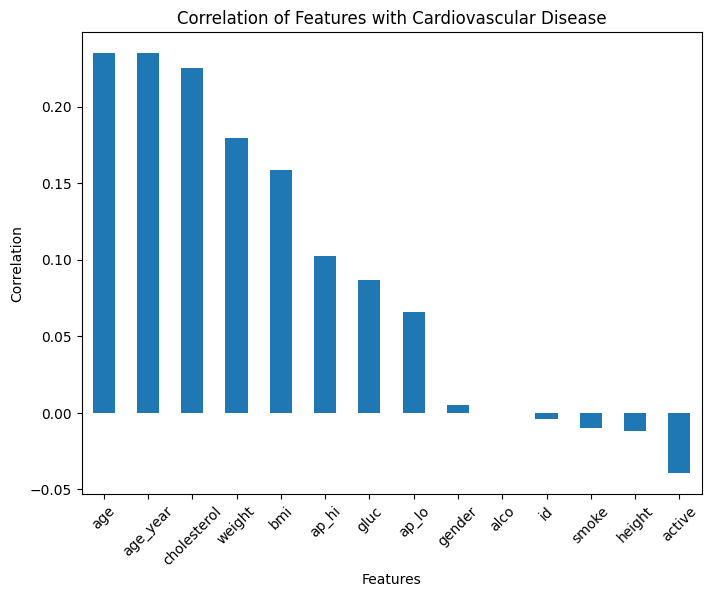

In [65]:
plt.figure(figsize=(8,6))

target_correlation.drop("cardio").plot(
    kind="bar"
)

plt.title("Correlation of Features with Cardiovascular Disease")
plt.xlabel("Features")
plt.ylabel("Correlation")

plt.xticks(rotation=45)

plt.show()

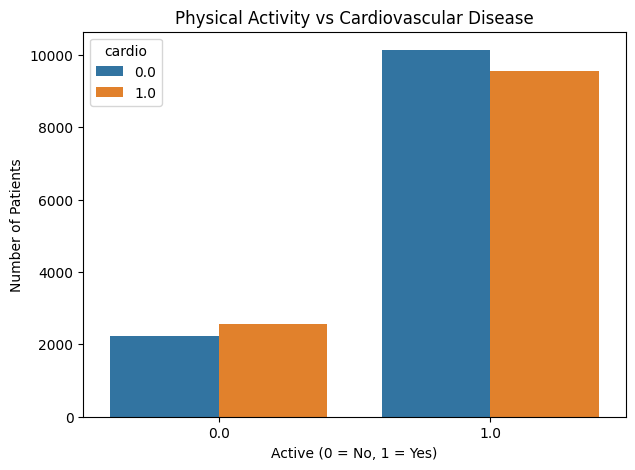

In [66]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="active",
    hue="cardio"
)

plt.title("Physical Activity vs Cardiovascular Disease")
plt.xlabel("Active (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")

plt.show()

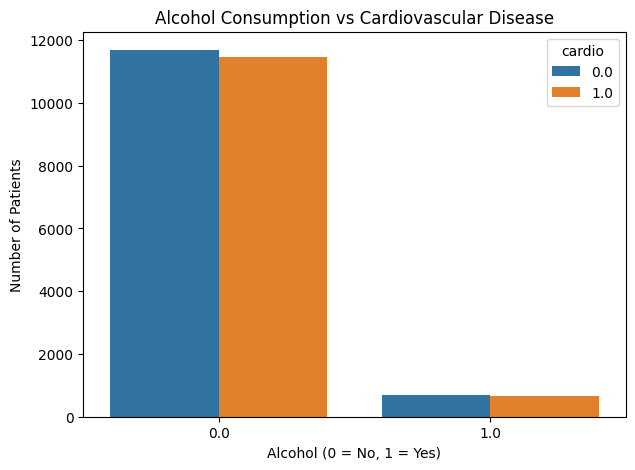

In [67]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="alco",
    hue="cardio"
)

plt.title("Alcohol Consumption vs Cardiovascular Disease")
plt.xlabel("Alcohol (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")

plt.show()

In [68]:
df["pulse_pressure"] = df["ap_hi"] - df["ap_lo"]

In [69]:
df["pulse_pressure"].describe()

,pulse_pressure
count,24490.000000
mean,29.645733
std,224.344995
min,-9860.000000
25%,40.000000
50%,40.000000
75%,50.000000
max,11410.000000


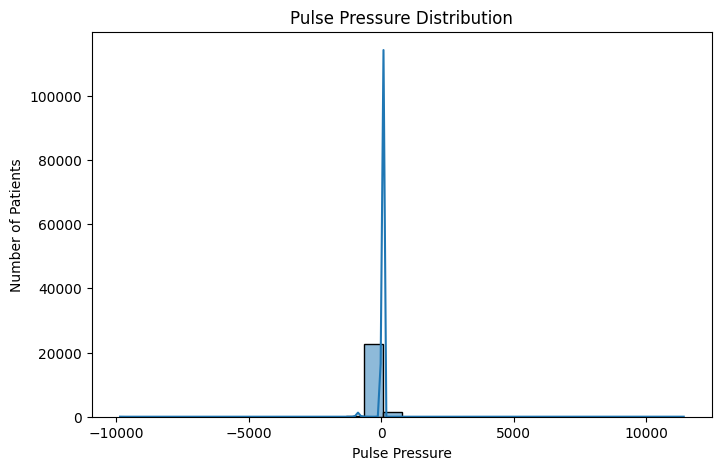

In [70]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="pulse_pressure",
    bins=30,
    kde=True
)

plt.title("Pulse Pressure Distribution")
plt.xlabel("Pulse Pressure")
plt.ylabel("Number of Patients")

plt.show()

**Feature** **Engineering**

In [71]:
# 1. Age ko Years mein Convert karna
df["age_year"] = df["age"] / 365.25

In [72]:
# Age ko integer me convert:
df["age_year"] = df["age_year"].astype(int)

In [73]:
df[["age", "age_year"]].head()

,age,age_year
0,18393,50
1,20228,55
2,18857,51
3,17623,48
4,17474,47


In [74]:
# BMI ka formula:

# BMI = Weight / Height²

# Height cm me hai, isliye pehle meter me convert karenge.

df["height_m"] = df["height"] / 100

In [75]:
df["bmi"] = df["weight"] / (df["height_m"] ** 2)

In [76]:
df[["height", "weight", "height_m", "bmi"]].head()

,height,weight,height_m,bmi
0,168,62.0,1.68,21.967120
1,156,85.0,1.56,34.927679
2,165,64.0,1.65,23.507805
3,169,82.0,1.69,28.710479
4,156,56.0,1.56,23.011177


In [77]:
df["bmi"].describe()

,bmi
count,24491.000000
mean,27.546532
std,6.367119
min,10.726644
25%,23.875115
50%,26.346494
75%,30.119376
max,298.666667


In [78]:
# BMI ko categories me divide kar sakte hain:
df["bmi_category"] = "Normal"

df.loc[df["bmi"] < 18.5, "bmi_category"] = "Underweight"

df.loc[
    (df["bmi"] >= 25) & (df["bmi"] < 30),
    "bmi_category"
] = "Overweight"

df.loc[
    df["bmi"] >= 30,
    "bmi_category"
] = "Obese"

In [79]:
df["bmi_category"].value_counts()

,count
bmi_category,
Normal,9107
Overweight,8768
Obese,6410
Underweight,206


In [80]:
# Pulse Pressure ka formula:

# Pulse Pressure = Systolic BP − Diastolic BP
df["pulse_pressure"] = df["ap_hi"] - df["ap_lo"]

In [81]:
df[["ap_hi", "ap_lo", "pulse_pressure"]].head()

,ap_hi,ap_lo,pulse_pressure
0,110.0,80.0,30.0
1,140.0,90.0,50.0
2,130.0,70.0,60.0
3,150.0,100.0,50.0
4,100.0,60.0,40.0


In [82]:
df["pulse_pressure"].describe()

,pulse_pressure
count,24490.000000
mean,29.645733
std,224.344995
min,-9860.000000
25%,40.000000
50%,40.000000
75%,50.000000
max,11410.000000


In [83]:
# Age ko groups me divide kar sakte hain:
df["age_group"] = pd.cut(
    df["age_year"],
    bins=[0, 40, 50, 60, 70, 100],
    labels=[
        "Below 40",
        "40-49",
        "50-59",
        "60-69",
        "70+"
    ],
    right=False
)

In [84]:
df["age_group"].value_counts()

,count
age_group,
50-59,12372
40-49,6969
60-69,4442
Below 40,708
70+,0


In [90]:
# Final Feature Engineering Check
df[
    [
        "age_year",
        "height_m",
        "bmi",
        "bmi_category",
        "pulse_pressure",
        "age_group",

    ]
].head(10)

,age_year,height_m,bmi,bmi_category,pulse_pressure,age_group
0,50,1.68,21.967120,Normal,30.0,50-59
1,55,1.56,34.927679,Obese,50.0,50-59
2,51,1.65,23.507805,Normal,60.0,50-59
3,48,1.69,28.710479,Overweight,50.0,40-49
4,47,1.56,23.011177,Normal,40.0,40-49
5,59,1.51,29.384676,Overweight,40.0,50-59
6,60,1.57,37.729725,Obese,50.0,60-69
7,61,1.78,29.983588,Overweight,40.0,60-69
8,48,1.58,28.440955,Overweight,40.0,40-49
9,54,1.64,25.282570,Overweight,50.0,50-59


In [ ]:
# Final Dataset Columns
print(df.columns.tolist())

In [88]:
# Final Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24491 entries, 0 to 24490
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   id              24491 non-null  int64   
 1   age             24491 non-null  int64   
 2   gender          24491 non-null  int64   
 3   height          24491 non-null  int64   
 4   weight          24491 non-null  float64 
 5   ap_hi           24490 non-null  float64 
 6   ap_lo           24490 non-null  float64 
 7   cholesterol     24490 non-null  float64 
 8   gluc            24490 non-null  float64 
 9   smoke           24490 non-null  float64 
 10  alco            24490 non-null  float64 
 11  active          24490 non-null  float64 
 12  cardio          24490 non-null  float64 
 13  age_year        24491 non-null  int64   
 14  bmi             24491 non-null  float64 
 15  pulse_pressure  24490 non-null  float64 
 16  height_m        24491 non-null  float64 
 17  bmi_category

In [89]:
# Feature Engineering ke baad Dataset Save karo
df.to_csv(
    "cardio_feature_engineered.csv",
    index=False
)

**Model** **Training**

In [91]:
df.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_year',
       'bmi', 'pulse_pressure', 'height_m', 'bmi_category', 'age_group'],
      dtype='object')

In [107]:
# Hum useful numerical/binary features lenge.
features = [
    "age_year",
    "gender",
    "height",
    "weight",
    "ap_hi",
    "ap_lo",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active",
    "bmi",
    "pulse_pressure"
]

X = df[features]
y = df["cardio"]

In [94]:
# traget
X = df[features]
y = df["cardio"]

In [98]:
# check
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (24491, 13)
y Shape: (24491,)


In [100]:
# X ka First 5 Rows
X.head()

,age_year,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,bmi,pulse_pressure
0,50,2,168,62.0,110.0,80.0,1.0,1.0,0.0,0.0,1.0,21.967120,30.0
1,55,1,156,85.0,140.0,90.0,3.0,1.0,0.0,0.0,1.0,34.927679,50.0
2,51,1,165,64.0,130.0,70.0,3.0,1.0,0.0,0.0,0.0,23.507805,60.0
3,48,2,169,82.0,150.0,100.0,1.0,1.0,0.0,0.0,1.0,28.710479,50.0
4,47,1,156,56.0,100.0,60.0,1.0,1.0,0.0,0.0,0.0,23.011177,40.0


In [101]:
# y ka First 5 Rows
y.head()

,cardio
0,0.0
1,1.0
2,1.0
3,1.0
4,0.0


In [102]:
# dono ko ake sath
print("X:")
display(X.head())

print("\ny:")
display(y.head())

X:


,age_year,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,bmi,pulse_pressure
0,50,2,168,62.0,110.0,80.0,1.0,1.0,0.0,0.0,1.0,21.967120,30.0
1,55,1,156,85.0,140.0,90.0,3.0,1.0,0.0,0.0,1.0,34.927679,50.0
2,51,1,165,64.0,130.0,70.0,3.0,1.0,0.0,0.0,0.0,23.507805,60.0
3,48,2,169,82.0,150.0,100.0,1.0,1.0,0.0,0.0,1.0,28.710479,50.0
4,47,1,156,56.0,100.0,60.0,1.0,1.0,0.0,0.0,0.0,23.011177,40.0



y:


,cardio
0,0.0
1,1.0
2,1.0
3,1.0
4,0.0


In [103]:
# missing values
print("Missing values in X:")
print(X.isnull().sum())

print("\nMissing values in y:")
print(y.isnull().sum())

Missing values in X:
age_year          0
gender            0
height            0
weight            0
ap_hi             1
ap_lo             1
cholesterol       1
gluc              1
smoke             1
alco              1
active            1
bmi               0
pulse_pressure    1
dtype: int64

Missing values in y:
1


**Train**-**Test** **Split**

In [115]:
from sklearn.model_selection import train_test_split

# X aur y me missing values wali rows remove karna
data = pd.concat([X, y], axis=1)

data = data.dropna()

# X aur y dobara banana
X = data[features]
y = data["cardio"]

# Missing values check
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Shape check
print("\nTraining Data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting Data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Missing values in X: 0
Missing values in y: 0

Training Data:
X_train: (19592, 13)
y_train: (19592,)

Testing Data:
X_test: (4898, 13)
y_test: (4898,)


In [116]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training target distribution:
cardio
0.0    0.504951
1.0    0.495049
Name: proportion, dtype: float64

Testing target distribution:
cardio
0.0    0.5049
1.0    0.4951
Name: proportion, dtype: float64


**Feature Scaling**

In [117]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (19592, 13)
X_test_scaled shape: (4898, 13)


In [118]:
# check
print(X_train_scaled[:5])

[[-1.88020357  1.37233252  1.29620545  0.55000098 -0.30279517 -0.08230218
  -0.53663525 -0.39249327  3.18802961 -0.24201088  0.49549785 -0.12033059
   0.05194535]
 [-0.8487979   1.37233252  0.44045477 -0.28840636 -0.30279517 -0.1271539
  -0.53663525 -0.39249327  3.18802961  4.13204559  0.49549785 -0.44071569
   0.09702   ]
 [ 1.50870079 -0.72868637  0.68495496  1.73774471  1.47168789  0.00740127
   2.42790944 -0.39249327 -0.31367337 -0.24201088  0.49549785  1.0938279
   0.14209464]
 [ 0.77198245  1.37233252  0.92945516 -0.14867181 -0.30279517 -0.08230218
  -0.53663525 -0.39249327 -0.31367337 -0.24201088  0.49549785 -0.51604445
   0.05194535]
 [-0.70145423  1.37233252  1.41845554 -0.77747731 -0.30279517 -0.08230218
  -0.53663525 -0.39249327 -0.31367337 -0.24201088  0.49549785 -1.16514232
   0.05194535]]


**Model training**

## ***Logistic Regerssion***

In [122]:
# Model import karna hai
from sklearn.linear_model import LogisticRegression

# Model evaluation ke liye required metrics import kar rahe hain
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Visualization ke liye matplotlib aur seaborn
import matplotlib.pyplot as plt
import seaborn as sns

# Model create karna
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Model train karna
logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression Model Successfully Trained!")

# Prediction
y_pred_logistic = logistic_model.predict(
    X_test_scaled
)

print("\nFirst 20 Predictions:")
print(y_pred_logistic[:20])


# Model Accuracy
accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

print("\nAccuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

# Precision
precision = precision_score(
    y_test,
    y_pred_logistic
)

print("Precision:", precision)

# Recall
recall = recall_score(
    y_test,
    y_pred_logistic
)

print("Recall:", recall)

# F1 Score
f1 = f1_score(
    y_test,
    y_pred_logistic
)

print("F1 Score:", f1)

# Classification Report

# Precision, Recall, F1-score aur Support
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_logistic
    )
)

# Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred_logistic
)

print("\nConfusion Matrix:")
print(cm)


Logistic Regression Model Successfully Trained!

First 20 Predictions:
[0. 0. 0. 0. 1. 0. 0. 1. 1. 0. 1. 1. 0. 0. 1. 1. 1. 0. 1. 0.]

Accuracy: 0.7068191098407514
Accuracy Percentage: 70.68191098407513 %
Precision: 0.7275655775425679
Recall: 0.6519587628865979
F1 Score: 0.6876903001304915

Classification Report:
              precision    recall  f1-score   support

         0.0       0.69      0.76      0.72      2473
         1.0       0.73      0.65      0.69      2425

    accuracy                           0.71      4898
   macro avg       0.71      0.71      0.71      4898
weighted avg       0.71      0.71      0.71      4898


Confusion Matrix:
[[1881  592]
 [ 844 1581]]


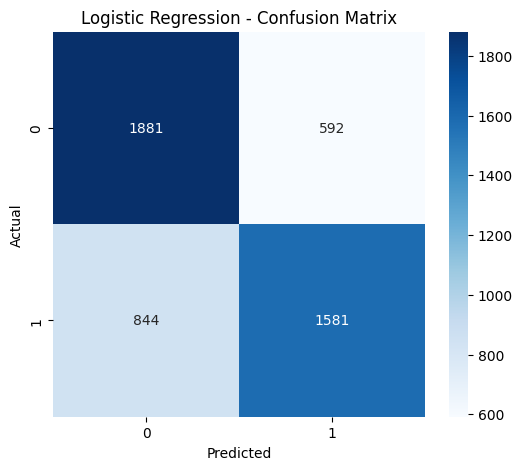

In [124]:
# Graph
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [129]:
# DECISION TREE CLASSIFIER
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Decision Tree model create
dt_model = DecisionTreeClassifier(random_state=42)

# 2. Model ko training data par train karna
dt_model.fit(X_train, y_train)

# 3. Test data par prediction
y_pred_dt = dt_model.predict(X_test)

# MODEL EVALUATION
# 4. Accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

# 5. Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

print("\nConfusion Matrix:")
print(cm_dt)

# 6. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

# ACTUAL VS PREDICTED
print("\nActual vs Predicted:")

comparison_dt = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_dt
})

print(comparison_dt.head(10))

# FEATURE IMPORTANCE
feature_importance = pd.Series(
    dt_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("\nFeature Importance:")
print(feature_importance)


Decision Tree Accuracy: 0.6290322580645161

Confusion Matrix:
[[1629  844]
 [ 973 1452]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.63      0.66      0.64      2473
         1.0       0.63      0.60      0.62      2425

    accuracy                           0.63      4898
   macro avg       0.63      0.63      0.63      4898
weighted avg       0.63      0.63      0.63      4898


Actual vs Predicted:
   Actual  Predicted
0     0.0        0.0
1     1.0        1.0
2     0.0        1.0
3     0.0        0.0
4     1.0        1.0
5     0.0        0.0
6     0.0        0.0
7     1.0        1.0
8     1.0        0.0
9     0.0        1.0

Feature Importance:
ap_hi             0.244252
bmi               0.203111
age_year          0.153689
weight            0.110304
height            0.108692
cholesterol       0.039570
ap_lo             0.029652
pulse_pressure    0.028560
gender            0.026424
gluc              0.018702
active          

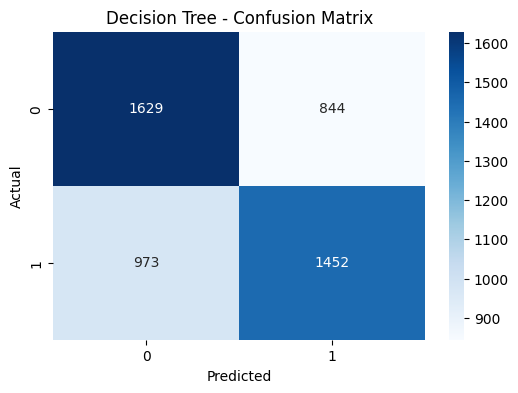

In [126]:
# Confusion Matrix ka graph
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree - Confusion Matrix")
plt.show()

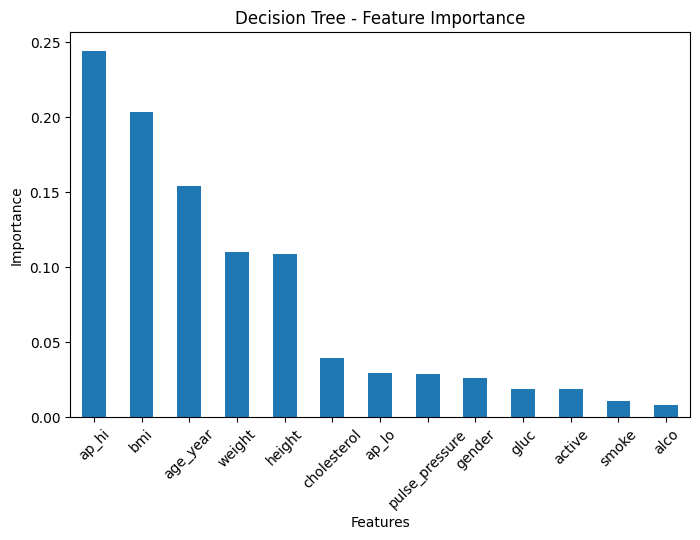

In [127]:
# Feature Importance graph
plt.figure(figsize=(8, 5))
feature_importance.plot(kind='bar')

plt.title("Decision Tree - Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

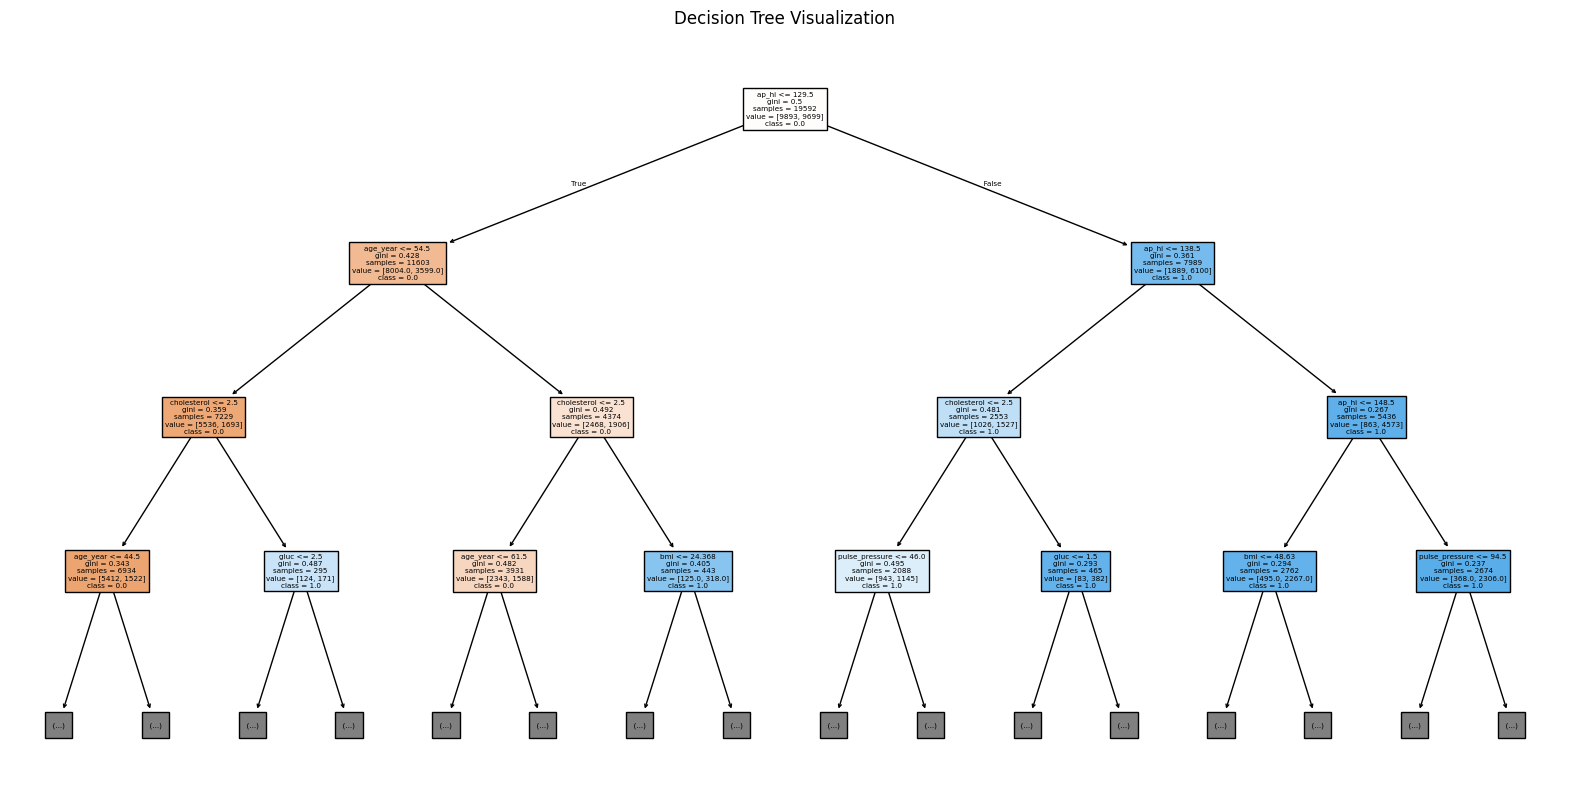

In [128]:
# DECISION TREE VISUALIZATION
plt.figure(figsize=(20, 10))

plot_tree(
    dt_model,
    feature_names=X_train.columns,
    class_names=[str(c) for c in dt_model.classes_],
    filled=True,
    max_depth=3
)

plt.title("Decision Tree Visualization")
plt.show()

**Random Forest**

In [130]:
# RANDOM FOREST CLASSIFIER
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Random Forest model create
# Random Forest multiple Decision Trees ko combine karke
# final prediction deta hai.
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# 2. Training data par model train karna
rf_model.fit(X_train, y_train)

# 3. Test data par prediction
y_pred_rf = rf_model.predict(X_test)

# MODEL EVALUATION
# 4. Accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_rf)

# 5. Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix:")
print(cm_rf)

# 6. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# ACTUAL VS PREDICTED
comparison_rf = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_rf
})
print("\nActual vs Predicted:")
print(comparison_rf.head(10))

# FEATURE IMPORTANCE
feature_importance_rf = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("\nFeature Importance:")
print(feature_importance_rf)


Random Forest Accuracy: 0.6931400571661903

Confusion Matrix:
[[1765  708]
 [ 795 1630]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.69      0.71      0.70      2473
         1.0       0.70      0.67      0.68      2425

    accuracy                           0.69      4898
   macro avg       0.69      0.69      0.69      4898
weighted avg       0.69      0.69      0.69      4898


Actual vs Predicted:
   Actual  Predicted
0     0.0        0.0
1     1.0        0.0
2     0.0        1.0
3     0.0        0.0
4     1.0        1.0
5     0.0        0.0
6     0.0        0.0
7     1.0        1.0
8     1.0        1.0
9     0.0        0.0

Feature Importance:
bmi               0.175567
age_year          0.155832
ap_hi             0.144555
weight            0.133716
height            0.126847
ap_lo             0.081303
pulse_pressure    0.063167
cholesterol       0.043398
gender            0.020775
gluc              0.019051
active          

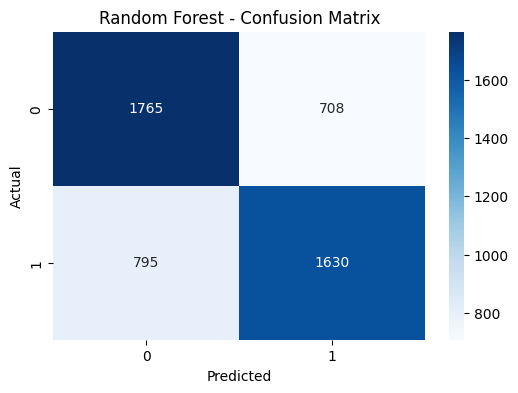

In [131]:
# Confusion Matrix ka graph
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")
plt.show()

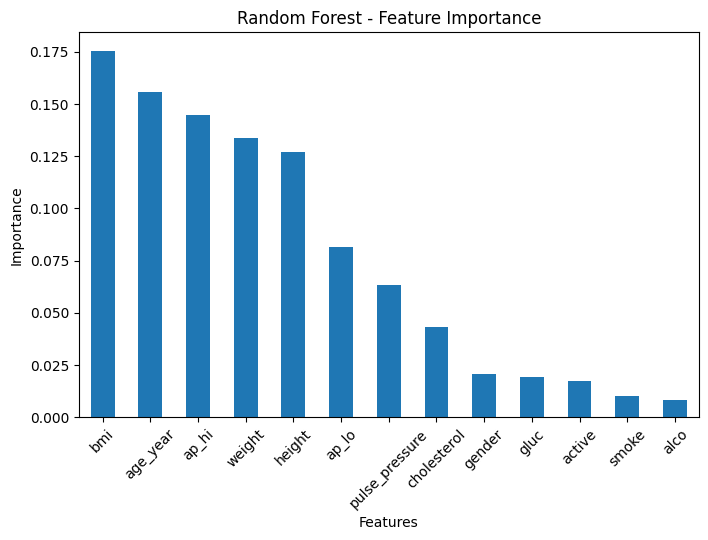

In [132]:
# Feature Importance graph
plt.figure(figsize=(8, 5))
feature_importance_rf.plot(kind='bar')

plt.title("Random Forest - Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

### **KNN(K-Nearest Neighbors)**

In [133]:
# KNN CLASSIFIER
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. KNN model create
# n_neighbors=5 ka matlab:
# prediction ke liye nearest 5 data points ko dekhega
knn_model = KNeighborsClassifier(n_neighbors=5)

# 2. Training data par model train karna
# KNN me scaled data use karna better hota hai
knn_model.fit(X_train_scaled, y_train)

# 3. Test data par prediction
y_pred_knn = knn_model.predict(X_test_scaled)

# MODEL EVALUATION
# 4. Accuracy
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", accuracy_knn)

# 5. Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
print("\nConfusion Matrix:")
print(cm_knn)

# 6. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

# ACTUAL VS PREDICTED
comparison_knn = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_knn
})
print("\nActual vs Predicted:")
print(comparison_knn.head(10))

KNN Accuracy: 0.680685994283381

Confusion Matrix:
[[1713  760]
 [ 804 1621]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.68      0.69      0.69      2473
         1.0       0.68      0.67      0.67      2425

    accuracy                           0.68      4898
   macro avg       0.68      0.68      0.68      4898
weighted avg       0.68      0.68      0.68      4898


Actual vs Predicted:
   Actual  Predicted
0     0.0        0.0
1     1.0        0.0
2     0.0        0.0
3     0.0        0.0
4     1.0        1.0
5     0.0        0.0
6     0.0        0.0
7     1.0        1.0
8     1.0        1.0
9     0.0        0.0


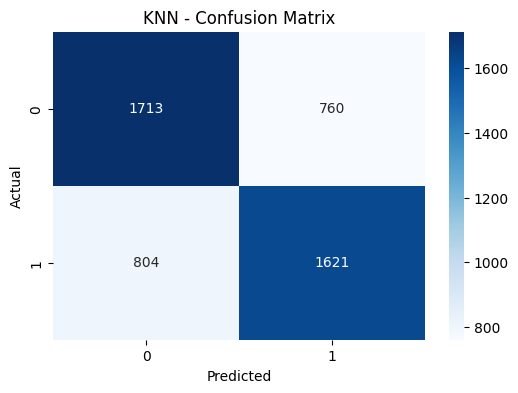

In [134]:
# Confusion Matrix ka graph
plt.figure(figsize=(6, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN - Confusion Matrix")
plt.show()

**SVM (Support Vector Machine)**

In [135]:
# SVM CLASSIFIER
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. SVM model create
# SVC classification ke liye use hota hai
svm_model = SVC(kernel='rbf', random_state=42)

# 2. Scaled training data par model train karna
svm_model.fit(X_train_scaled, y_train)

# 3. Test data par prediction
y_pred_svm = svm_model.predict(X_test_scaled)

# MODEL EVALUATION
# 4. Accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", accuracy_svm)

# 5. Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
print("\nConfusion Matrix:")
print(cm_svm)

# 6. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

# ACTUAL VS PREDICTED
comparison_svm = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_svm
})
print("\nActual vs Predicted:")
print(comparison_svm.head(10))

SVM Accuracy: 0.7121273989383422

Confusion Matrix:
[[1911  562]
 [ 848 1577]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.69      0.77      0.73      2473
         1.0       0.74      0.65      0.69      2425

    accuracy                           0.71      4898
   macro avg       0.71      0.71      0.71      4898
weighted avg       0.71      0.71      0.71      4898


Actual vs Predicted:
   Actual  Predicted
0     0.0        0.0
1     1.0        0.0
2     0.0        0.0
3     0.0        0.0
4     1.0        1.0
5     0.0        0.0
6     0.0        0.0
7     1.0        1.0
8     1.0        1.0
9     0.0        0.0


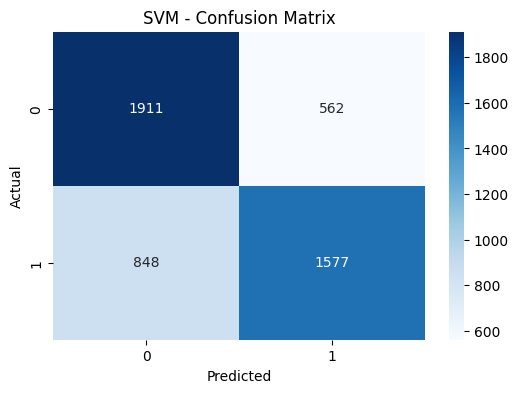

In [136]:
# Confusion Matrix ka graph
plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM - Confusion Matrix")
plt.show()

In [140]:
# XGBOOST CLASSIFIER
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. XGBoost model create
# n_estimators = kitne boosting trees banenge
# max_depth = tree ki maximum depth
# learning_rate = model kitni speed se learn karega
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

# 2. Training data par model train karna
xgb_model.fit(X_train, y_train)

# 3. Test data par prediction
y_pred_xgb = xgb_model.predict(X_test)

# MODEL EVALUATION
# 4. Accuracy
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print("XGBoost Accuracy:", accuracy_xgb)

# 5. Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("\nConfusion Matrix:")
print(cm_xgb)

# 6. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

# ACTUAL VS PREDICTED
comparison_xgb = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_xgb
})
print("\nActual vs Predicted:")
print(comparison_xgb.head(10))

# FEATURE IMPORTANCE
feature_importance_xgb = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("\nFeature Importance:")
print(feature_importance_xgb)

XGBoost Accuracy: 0.7160065332788893

Confusion Matrix:
[[1903  570]
 [ 821 1604]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.70      0.77      0.73      2473
         1.0       0.74      0.66      0.70      2425

    accuracy                           0.72      4898
   macro avg       0.72      0.72      0.71      4898
weighted avg       0.72      0.72      0.72      4898


Actual vs Predicted:
   Actual  Predicted
0     0.0          0
1     1.0          0
2     0.0          0
3     0.0          0
4     1.0          1
5     0.0          0
6     0.0          0
7     1.0          1
8     1.0          1
9     0.0          0

Feature Importance:
ap_hi             0.552185
cholesterol       0.103972
age_year          0.099098
ap_lo             0.053749
active            0.038237
weight            0.032432
bmi               0.024547
smoke             0.020755
gluc              0.020188
pulse_pressure    0.016671
gender            0.01

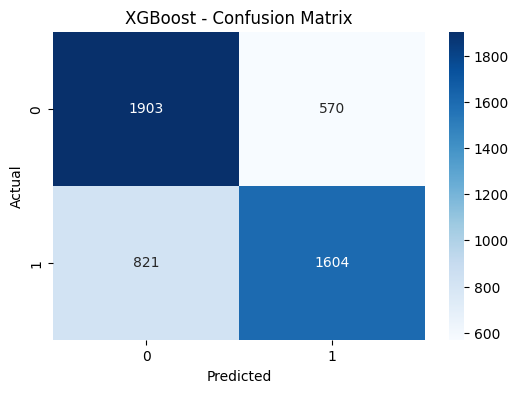

In [138]:
# Confusion Matrix ka graph
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost - Confusion Matrix")
plt.show()


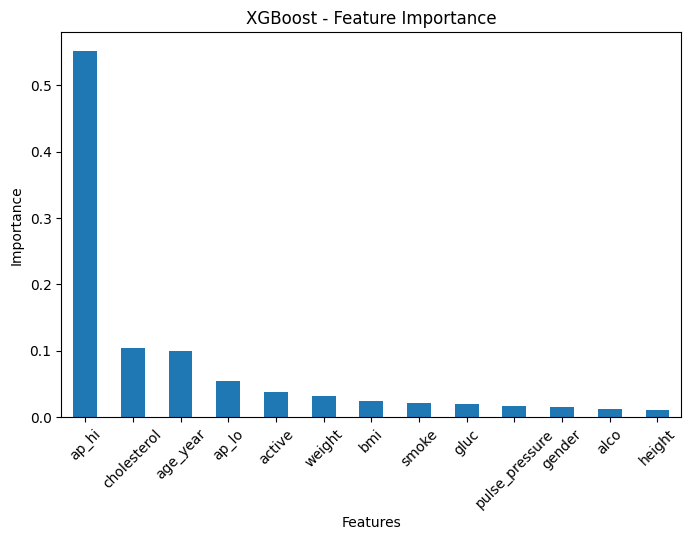

In [139]:
# Feature Importance graph
plt.figure(figsize=(8, 5))
feature_importance_xgb.plot(kind='bar')

plt.title("XGBoost - Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

In [142]:
# ==========================================
# LOGISTIC REGRESSION PREDICTION
# ==========================================

# Logistic Regression model se test data ki prediction
y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Logistic Regression prediction completed.")

Logistic Regression prediction completed.


In [145]:
# Sabhi models ki predictions ko ek dictionary me store karna

predictions = {
    "Logistic Regression": y_pred_logistic,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "KNN": y_pred_knn,
    "SVM": y_pred_svm,
    "XGBoost": y_pred_xgb
}

# Check karne ke liye
print(predictions.keys())

dict_keys(['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN', 'SVM', 'XGBoost'])


## **Final Evaluation**

In [146]:
# FINAL MODEL EVALUATION
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Sabhi models ki predictions
predictions = {
    "Logistic Regression": y_pred_logistic,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "KNN": y_pred_knn,
    "SVM": y_pred_svm,
    "XGBoost": y_pred_xgb
}

# 2. Har model ke evaluation scores
results = []

for model_name, prediction in predictions.items():

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, prediction),
        "Precision": precision_score(
            y_test, prediction, average="weighted"
        ),
        "Recall": recall_score(
            y_test, prediction, average="weighted"
        ),
        "F1 Score": f1_score(
            y_test, prediction, average="weighted"
        )
    })

# 3. Results ko DataFrame me convert karna
results_df = pd.DataFrame(results)

# Accuracy ke according highest model ko upar lana
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

# 4. Final comparison table
print("FINAL MODEL COMPARISON")
print("=" * 70)
display(results_df)

# 5. Accuracy Comparison Graph

# 6. All Metrics Comparison Graph

# 7. Best Model
best_model = results_df.iloc[0]
print("\nBEST MODEL")
print("=" * 40)

print("Model:", best_model["Model"])
print("Accuracy:", round(best_model["Accuracy"], 4))
print("Precision:", round(best_model["Precision"], 4))
print("Recall:", round(best_model["Recall"], 4))
print("F1 Score:", round(best_model["F1 Score"], 4))

FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.716007,0.718016,0.716007,0.715115
1,SVM,0.712127,0.714733,0.712127,0.710976
2,Logistic Regression,0.706819,0.708738,0.706819,0.705892
3,Random Forest,0.693140,0.693277,0.693140,0.692990
4,KNN,0.680686,0.680688,0.680686,0.680632
5,Decision Tree,0.629032,0.629199,0.629032,0.628679



BEST MODEL
Model: XGBoost
Accuracy: 0.716
Precision: 0.718
Recall: 0.716
F1 Score: 0.7151


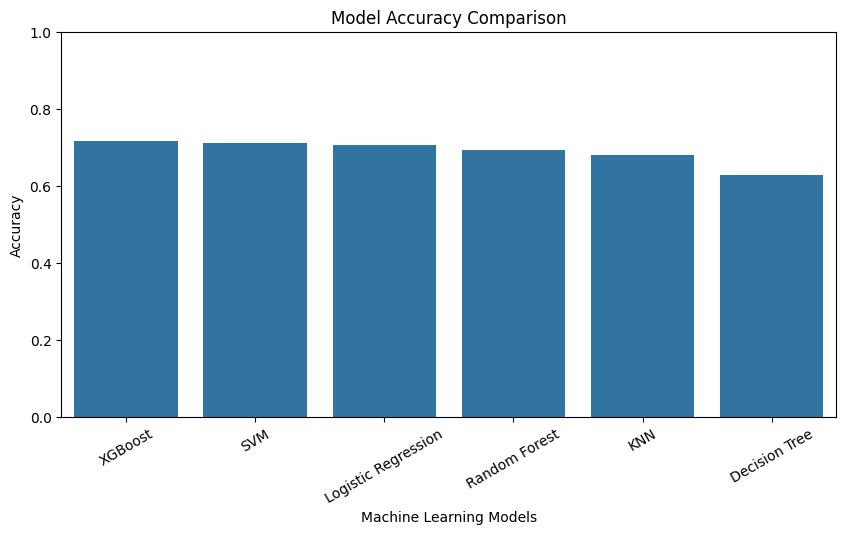

In [147]:
# 5. Accuracy Comparison Graph
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=30)
plt.ylim(0, 1)

plt.show()

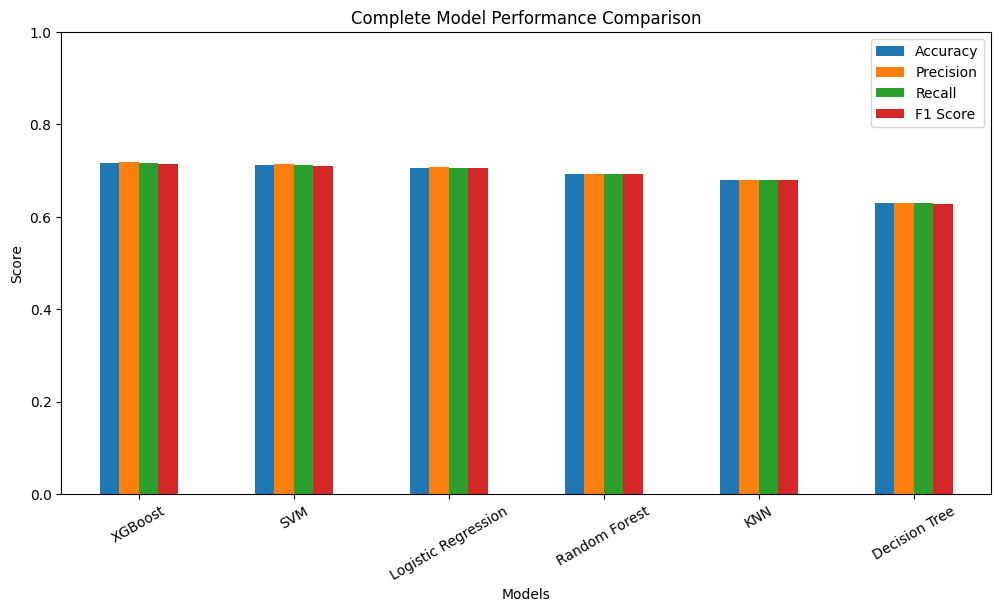

In [148]:
# 6. All Metrics Comparison Graph
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

results_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Complete Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("Score")

plt.xticks(rotation=30)
plt.ylim(0, 1)

plt.legend()
plt.show()